In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np

import pingouin as pg
import pycircstat2 as circ

import matplotlib.pyplot as plt

In [ ]:
working_path = Path(r"..path/to/some/folder")

In [12]:
result_list = [
    path for path in working_path.glob('**/*results_PLV.csv')
    if 'undecided' not in str(path) and 'hemispheres' not in str(path)
]

In [35]:
overall_df = pd.DataFrame()
ratio_sig_per_slice = []
for path in result_list:
    df_tmp = pd.read_csv(path)
    sign_tmp = df_tmp[df_tmp['p_value']<0.05]
    overall_df = pd.concat([overall_df, df_tmp], ignore_index=True)
    ratio_sig_per_slice.append(sign_tmp.shape[0] / df_tmp.shape[0])

ratio_sig_per_slice = np.array(ratio_sig_per_slice)

In [61]:
significant_df = overall_df[overall_df['p_value']<0.05]
non_significant_df = overall_df[overall_df['p_value']>=0.05]

In [ ]:
overall_ratio_significant = significant_df.shape[0] / overall_df.shape[0]

In [225]:
result_angular_randomisation_test = circ.hypothesis.angular_randomisation_test([significant_df['Phase Diff (radians)'], non_significant_df['Phase Diff (radians)']], verbose=True, n_simulation=1000)

Angular Randomization Test (ART) for Homogeneity
-------------------------------------------------
H0: The two samples come from the same population.
HA: The two samples do not come from the same population.

Observed Test Statistic: 15863967.53548
P-value: 0.00100 ***


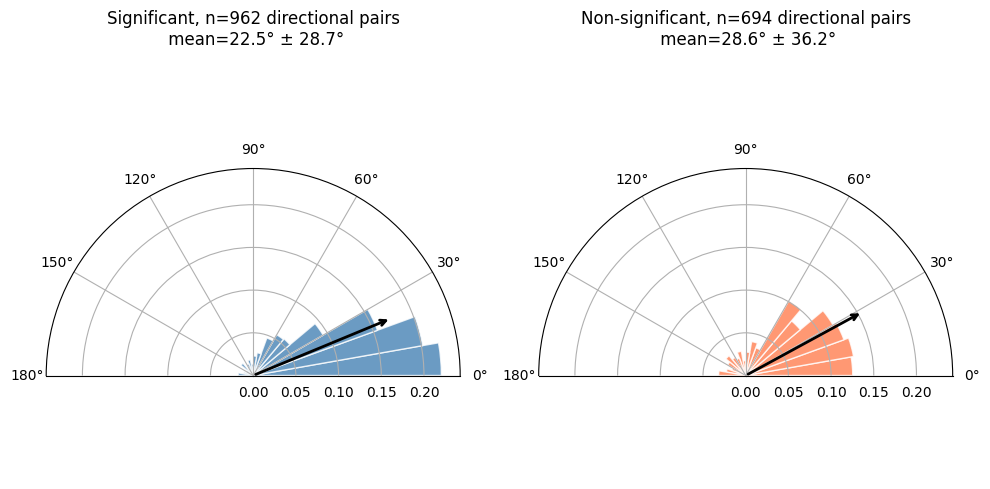

In [229]:
from scipy.stats import circmean, circstd
import numpy as np
import matplotlib.pyplot as plt

def fold_angles(angles):
    """Fold angles to [0, π] — direction-agnostic phase difference."""
    wrapped = (angles + np.pi) % (2 * np.pi) - np.pi  # wrap to [-π, π]
    return np.abs(wrapped)                              # fold to [0, π]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                          subplot_kw=dict(projection='polar'))

all_counts = []
for angles in [significant_df['Phase Diff (radians)'].values,
               non_significant_df['Phase Diff (radians)'].values]:
    angles_folded = fold_angles(angles)
    bins = np.linspace(0, np.pi, 19)
    counts, _ = np.histogram(angles_folded, bins=bins)
    all_counts.append(counts / counts.sum())

max_count = max(d.max() for d in all_counts)

for ax, angles, counts, title, color in zip(
    axes,
    [significant_df['Phase Diff (radians)'].values,
     non_significant_df['Phase Diff (radians)'].values],
    all_counts,
    [f'Significant, n={significant_df.shape[0]} directional pairs', f'Non-significant, n={non_significant_df.shape[0]} directional pairs'],
    ['steelblue', 'coral']
):
    angles_folded = fold_angles(angles)
    bins = np.linspace(0, np.pi, 19)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = bins[1] - bins[0]

    ax.bar(bin_centers, counts, width=width, color=color, alpha=0.8, edgecolor='white')

    mean_dir = circmean(angles_folded, low=0, high=np.pi)
    mean_r = np.abs(np.mean(np.exp(1j * angles_folded))) * max_count
    std_dir = circstd(angles_folded, low=0, high=np.pi)

    ax.annotate('', xy=(mean_dir, mean_r), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_ylim(0, max_count * 1.1)
    ax.set_title(f'{title}\n mean={np.degrees(mean_dir):.1f}° ± {np.degrees(std_dir):.1f}°', pad=15)

plt.tight_layout()
plt.show()

In [228]:
import pingouin as pg
import numpy as np

# Compute cos of folded angles for each group
cos_significant = np.cos(significant_df['Phase Diff (radians)'].values)
print(f'Mean Cosine significant: {np.mean(cos_significant)}')
cos_non_significant = np.cos(non_significant_df['Phase Diff (radians)'].values)
print(f'Mean Cosine non-significant {np.mean(cos_non_significant)}')

print("\n=== Significant vs Non-significant (Welch t-test) ===")
print(pg.ttest(cos_significant, cos_non_significant))

# --- Test the two distributions against each other (non-parametric) ---
print("\n=== Significant vs Non-significant (Mann-Whitney) ===")
print(pg.mwu(cos_significant, cos_non_significant))



Mean Cosine significant: 0.660098072148936
Mean Cosine non-significant 0.4596060768894959

=== Significant vs Non-significant (Welch t-test) ===
               T          dof alternative         p_val          CI95  \
T_test  6.748151  1309.237766   two-sided  2.242715e-11  [0.14, 0.26]   

         cohen_d  power       BF10  
T_test  0.346773    1.0  2.639e+08  

=== Significant vs Non-significant (Mann-Whitney) ===
        U_val alternative         p_val       RBC      CLES
MWU  413537.0   two-sided  1.013847e-16  0.238825  0.619412


In [214]:
# --- Permutation test ---
observed_diff = np.median(cos_significant) - np.median(cos_non_significant)
combined = np.concatenate([cos_significant, cos_non_significant])
n_sig = len(cos_significant)
n_permutations = 10000

perm_diffs = np.empty(n_permutations)
rng = np.random.default_rng(42)
for i in range(n_permutations):
    shuffled = rng.permutation(combined)
    perm_diffs[i] = np.median(shuffled[:n_sig]) - np.median(shuffled[n_sig:])

p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"\n=== Permutation test (n={n_permutations}) ===")
print(f"Observed median difference: {observed_diff:.3f}")
print(f"p-value (two-tailed):       {p_perm:.4f}")


=== Permutation test (n=10000) ===
Observed median difference: 0.154
p-value (two-tailed):       0.0000


In [141]:
# Pearson
print('\nPearson Results')
pearson_plv_distance_sig = pg.corr(significant_df['distance_px'], significant_df['PLV Value'],  method='pearson')
print(f'Significant PLV vs Distance \n {pearson_plv_distance_sig}\n-----------\n')

pearson_plv_distance_non = pg.corr(non_significant_df['distance_px'], non_significant_df['PLV Value'],  method='pearson')
print(f'Non significant PLV vs Distance \n {pearson_plv_distance_non}\n-----------')


# Spearman
print('\nSpearman Results')
spearman_plv_distance_sig = pg.corr(significant_df['distance_px'], significant_df['PLV Value'] , method='spearman')
print(f'Significant PLV vs Distance \n {spearman_plv_distance_sig}\n-----------\n')

pearson_plv_distance_non = pg.corr(non_significant_df['distance_px'], non_significant_df['PLV Value'], method='spearman')
print(f'Non significant PLV vs Distance \n {pearson_plv_distance_non}\n-----------\n')


Pearson Results
Significant PLV vs Distance 
            n         r            CI95         p_val       BF10  power
pearson  962 -0.249552  [-0.31, -0.19]  4.008528e-15  9.606e+11    1.0
-----------

Non significant PLV vs Distance 
            n       r            CI95         p_val       BF10  power
pearson  694 -0.2623  [-0.33, -0.19]  2.205566e-12  2.279e+09    1.0
-----------

Spearman Results
Significant PLV vs Distance 
             n        r            CI95         p_val  power
spearman  962 -0.25348  [-0.31, -0.19]  1.434450e-15    1.0
-----------

Non significant PLV vs Distance 
             n        r            CI95         p_val  power
spearman  694 -0.28528  [-0.35, -0.22]  1.836207e-14    1.0
-----------



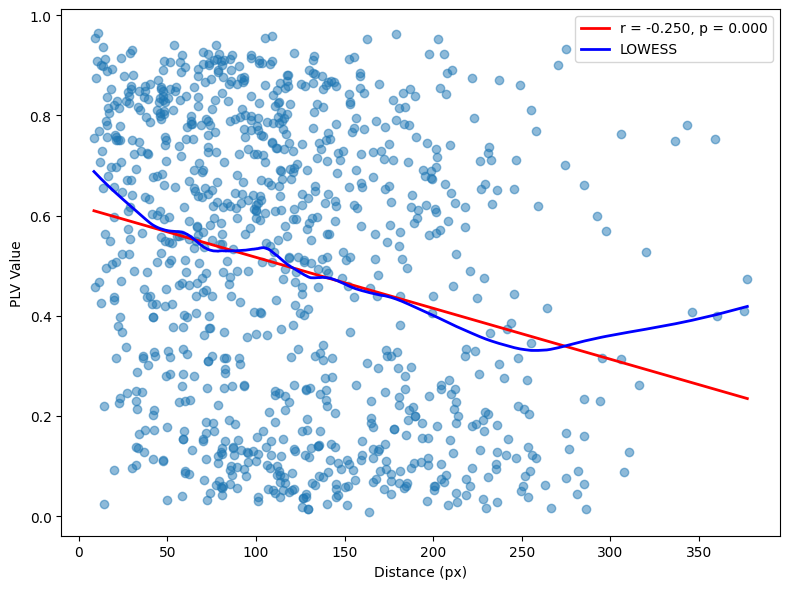

In [147]:
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess


fig, ax = plt.subplots(figsize=(8, 6))

x = significant_df['distance_px']
y = significant_df['PLV Value']

# Scatter
ax.scatter(x, y, alpha=0.5)

# Linear regression
slope, intercept, r, p, se = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='red', lw=2, 
        label=f'r = {r:.3f}, p = {p:.3f}')

smoothed = lowess(y, x, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='blue', lw=2, label='LOWESS')


ax.set_xlabel('Distance (px)')
ax.set_ylabel('PLV Value')
ax.legend()
plt.tight_layout()
plt.show()

Observed r = -0.250
Permutation p = 0.000


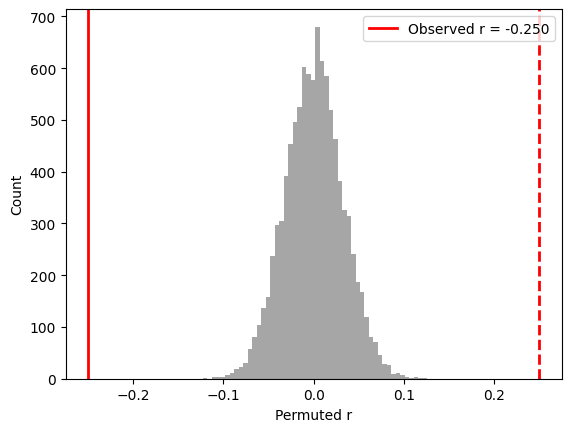

In [178]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

x = significant_df['distance_px'].values
y = significant_df['PLV Value']

# Observed correlation
r_obs, _ = pearsonr(x, y)

# Permutation test
n_permutations = 10000
r_perm = np.zeros(n_permutations)

for i in range(n_permutations):
    y_shuffled = np.random.permutation(y)
    r_perm[i], _ = pearsonr(x, y_shuffled)

# P-value = proportion of permuted r more extreme than observed
p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))

print(f'Observed r = {r_obs:.3f}')
print(f'Permutation p = {p_perm:.3f}')

# Visualise
plt.hist(r_perm, bins=50, color='grey', alpha=0.7)
plt.axvline(r_obs, color='red', lw=2, label=f'Observed r = {r_obs:.3f}')
plt.axvline(-r_obs, color='red', lw=2, linestyle='--')
plt.xlabel('Permuted r')
plt.ylabel('Count')
plt.legend()
plt.show()

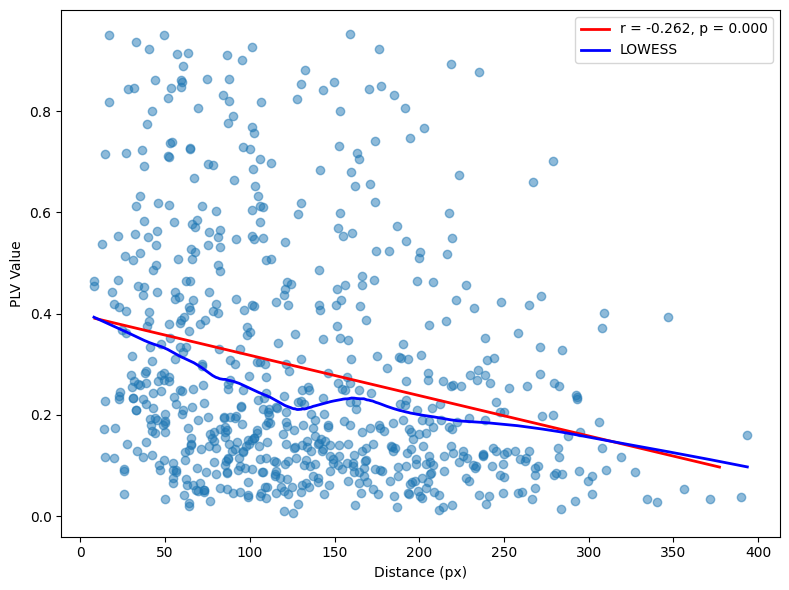

In [150]:
fig, ax = plt.subplots(figsize=(8, 6))

x1 = non_significant_df['distance_px']
y1 = non_significant_df['PLV Value']

# Scatter
ax.scatter(x1, y1, alpha=0.5)

# Linear regression
slope, intercept, r, p, se = linregress(x1, y1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='red', lw=2, 
        label=f'r = {r:.3f}, p = {p:.3f}')

smoothed = lowess(y1, x1, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='blue', lw=2, label='LOWESS')


ax.set_xlabel('Distance (px)')
ax.set_ylabel('PLV Value')
ax.legend()
plt.tight_layout()
plt.show()

Observed r = -0.262
Permutation p = 0.000


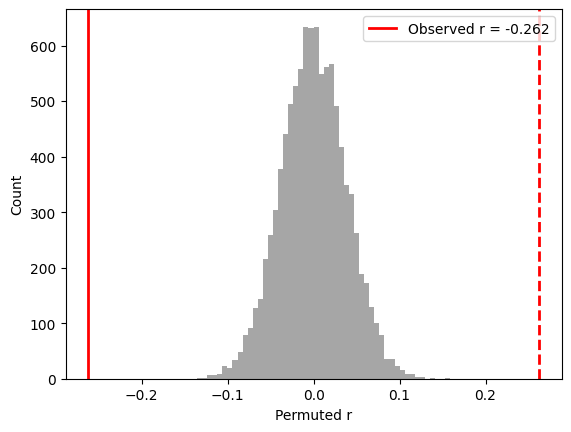

In [179]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

x = non_significant_df['distance_px'].values
y = non_significant_df['PLV Value']

# Observed correlation
r_obs, _ = pearsonr(x, y)

# Permutation test
n_permutations = 10000
r_perm = np.zeros(n_permutations)

for i in range(n_permutations):
    y_shuffled = np.random.permutation(y)
    r_perm[i], _ = pearsonr(x, y_shuffled)

# P-value = proportion of permuted r more extreme than observed
p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))

print(f'Observed r = {r_obs:.3f}')
print(f'Permutation p = {p_perm:.3f}')

# Visualise
plt.hist(r_perm, bins=50, color='grey', alpha=0.7)
plt.axvline(r_obs, color='red', lw=2, label=f'Observed r = {r_obs:.3f}')
plt.axvline(-r_obs, color='red', lw=2, linestyle='--')
plt.xlabel('Permuted r')
plt.ylabel('Count')
plt.legend()
plt.show()

In [164]:
#Pearson phas diff distance
print('\nPearson Results')
pearson_phase_distance_sig = pg.corr(significant_df['distance_px'],  np.cos(significant_df['Phase Diff (radians)']),  method='pearson')
print(f'Significant cos(Phase Diff) vs Distance \n {pearson_phase_distance_sig}\n-----------\n')
#Spearman phase diff distance
spearman_phase_distance = pg.corr(significant_df['distance_px'],  np.cos(significant_df['Phase Diff (radians)']),  method='spearman')
print(f'Significant cos(Phase  Diff) vs Distance \n {spearman_phase_distance}\n-----------')




Pearson Results
Significant cos(Phase Diff) vs Distance 
            n         r            CI95         p_val       BF10     power
pearson  962 -0.171116  [-0.23, -0.11]  9.301082e-08  6.145e+04  0.999656
-----------

Significant cos(Phase  Diff) vs Distance 
             n         r            CI95         p_val     power
spearman  962 -0.213202  [-0.27, -0.15]  2.372111e-11  0.999999
-----------


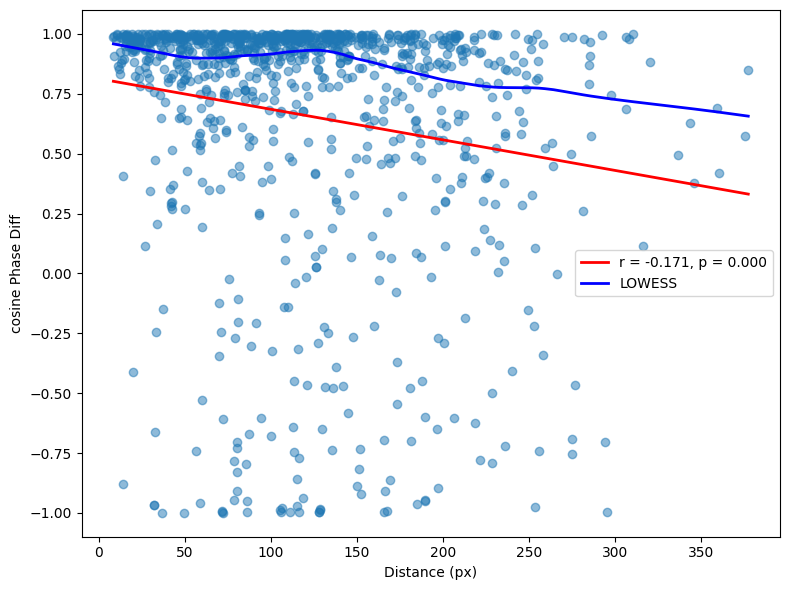

In [168]:
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess


fig, ax = plt.subplots(figsize=(8, 6))

x = significant_df['distance_px']
y = np.cos(significant_df['Phase Diff (radians)'])

# Scatter
ax.scatter(x, y, alpha=0.5)

# Linear regression
slope, intercept, r, p, se = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='red', lw=2, 
        label=f'r = {r:.3f}, p = {p:.3f}')

smoothed = lowess(y, x, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='blue', lw=2, label='LOWESS')


ax.set_xlabel('Distance (px)')
ax.set_ylabel('cosine Phase Diff')
ax.legend()
plt.tight_layout()
plt.show()

Observed r = -0.171
Permutation p = 0.000


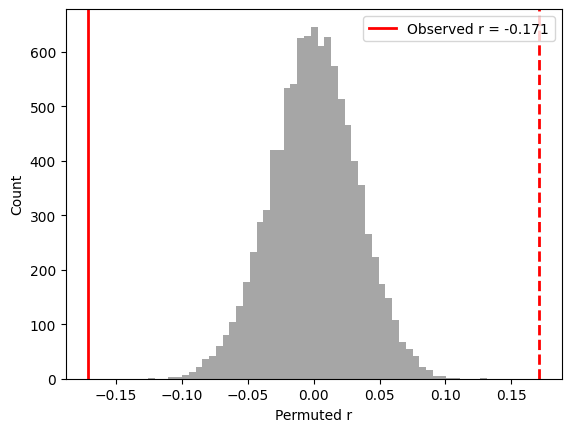

In [175]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

x = significant_df['distance_px'].values
y = np.cos(significant_df['Phase Diff (radians)'])

# Observed correlation
r_obs, _ = pearsonr(x, y)

# Permutation test
n_permutations = 10000
r_perm = np.zeros(n_permutations)

for i in range(n_permutations):
    y_shuffled = np.random.permutation(y)
    r_perm[i], _ = pearsonr(x, y_shuffled)

# P-value = proportion of permuted r more extreme than observed
p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))

print(f'Observed r = {r_obs:.3f}')
print(f'Permutation p = {p_perm:.3f}')

# Visualise
plt.hist(r_perm, bins=50, color='grey', alpha=0.7)
plt.axvline(r_obs, color='red', lw=2, label=f'Observed r = {r_obs:.3f}')
plt.axvline(-r_obs, color='red', lw=2, linestyle='--')
plt.xlabel('Permuted r')
plt.ylabel('Count')
plt.legend()
plt.show()

In [192]:
# Pearson
print('\nPearson Results')
pearson_plv_phase_sig = pg.corr(np.cos(significant_df['Phase Diff (radians)']), significant_df['PLV Value'],  method='pearson')
print(f'Significant cos(Phase Diff) vs PLV \n {pearson_plv_phase_sig}\n-----------\n')

spearam_plv_phase_sig = pg.corr(np.cos(significant_df['Phase Diff (radians)']), significant_df['PLV Value'],  method='spearman')
print(f'Significant cos(Phase Diff) vs PLV \n {spearam_plv_phase_sig}\n-----------')


Pearson Results
Significant cos(Phase Diff) vs PLV 
            n        r          CI95         p_val       BF10  power
pearson  962  0.58858  [0.55, 0.63]  9.582363e-91  1.205e+87    1.0
-----------

Significant cos(Phase Diff) vs PLV 
             n        r          CI95         p_val  power
spearman  962  0.57767  [0.53, 0.62]  1.020421e-86    1.0
-----------


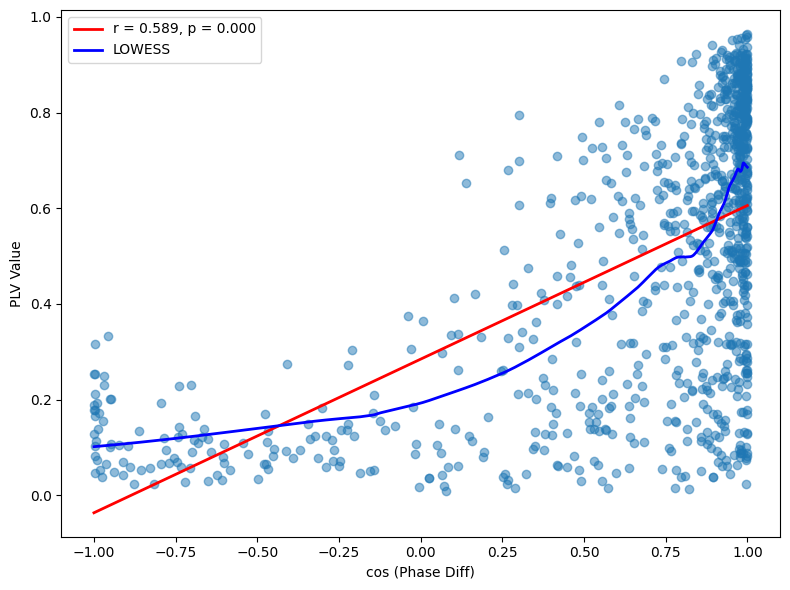

In [191]:
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess


fig, ax = plt.subplots(figsize=(8, 6))

x = np.cos(significant_df['Phase Diff (radians)'])
y = significant_df['PLV Value']

# Scatter
ax.scatter(x, y, alpha=0.5)

# Linear regression
slope, intercept, r, p, se = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='red', lw=2, 
        label=f'r = {r:.3f}, p = {p:.3f}')

smoothed = lowess(y, x, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='blue', lw=2, label='LOWESS')


ax.set_xlabel('cos (Phase Diff)')
ax.set_ylabel('PLV Value')
ax.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Pair count')

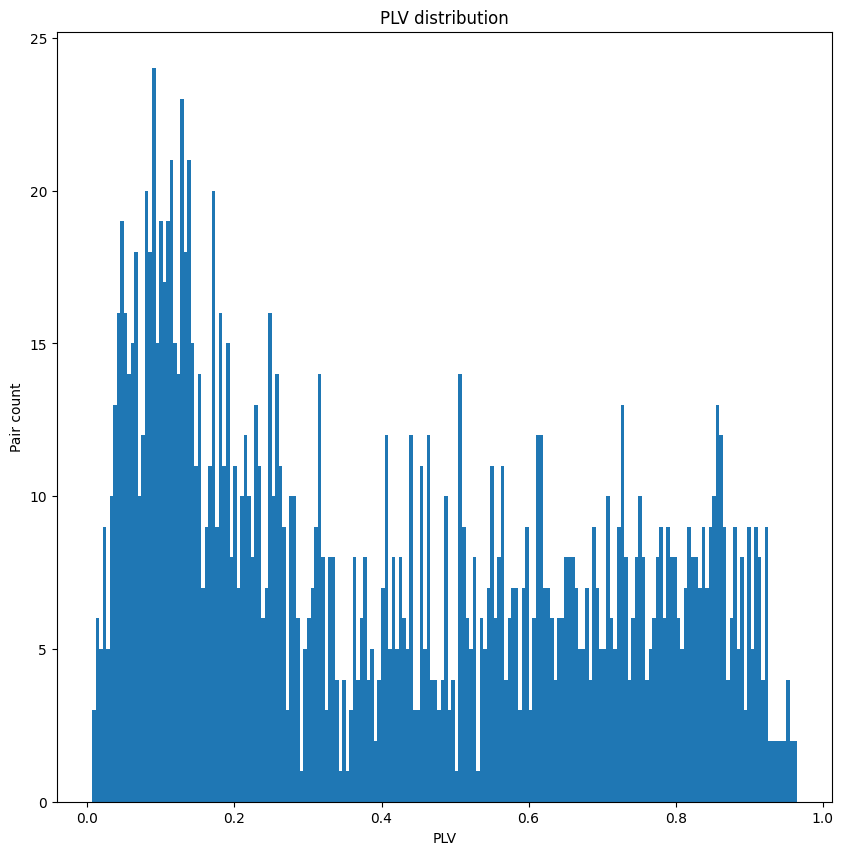

In [244]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.hist(overall_df['PLV Value'], bins=200)
plt.title('PLV distribution')
plt.xlabel('PLV')
plt.ylabel('Pair count')